/var/folders/tv/n34_b53j7zj29rwp532_xsmw0000gn/T/ipykernel_40320/92705980.py:188: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  plt.savefig("pinn_newton_cooling_comparison.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
/opt/anaconda3/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


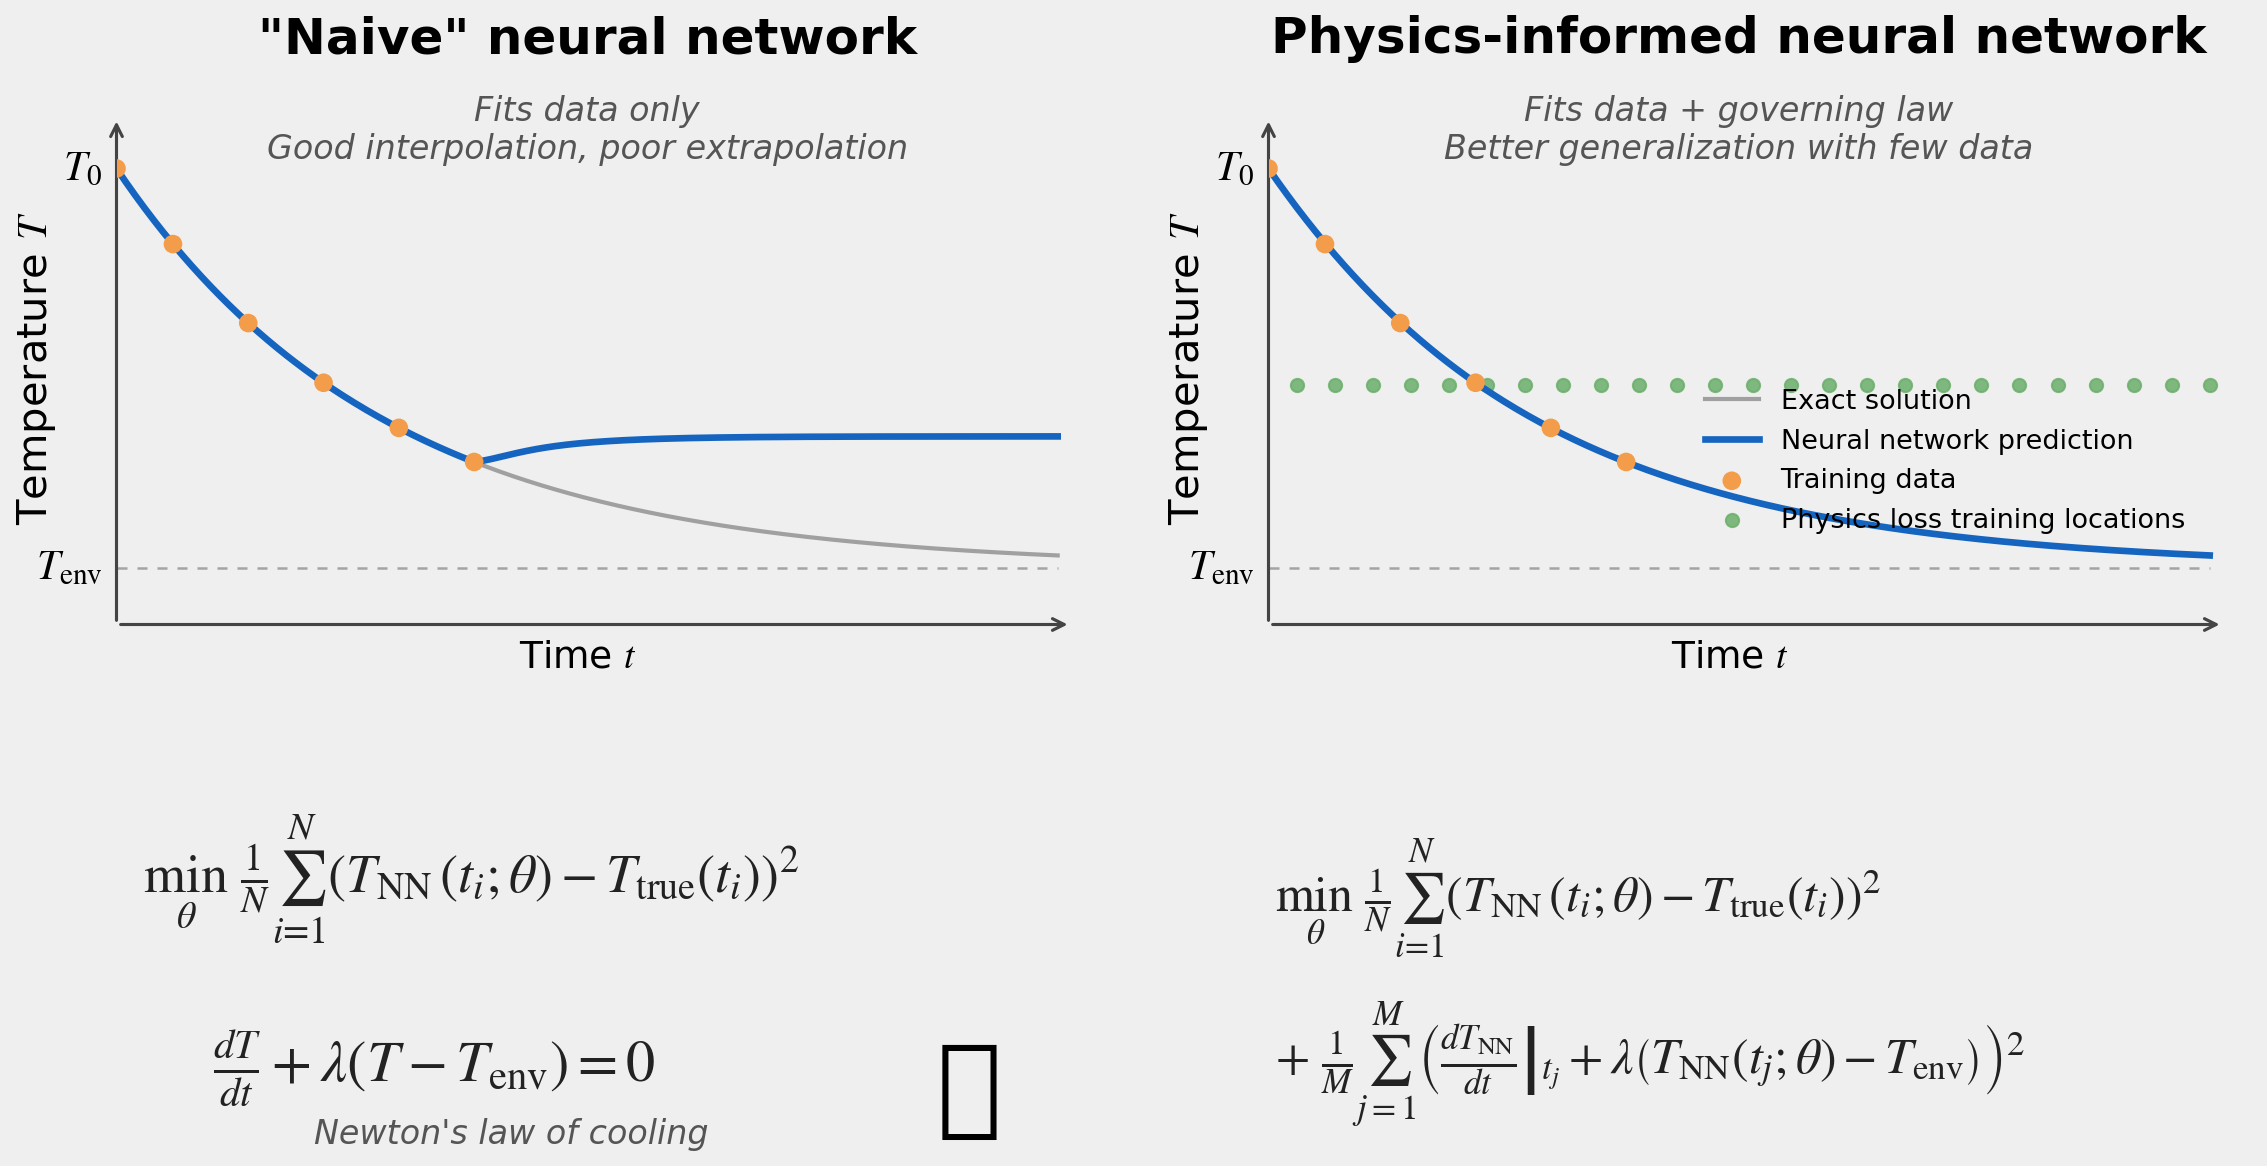

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) PARAMÈTRES PHYSIQUES : loi de refroidissement de Newton
# ============================================================

T_env = 20.0     # température ambiante
T0 = 90.0        # température initiale
lam = 0.35       # vitesse de refroidissement

# temps
t = np.linspace(0, 10, 400)

# solution exacte
T_true = T_env + (T0 - T_env) * np.exp(-lam * t)

# ============================================================
# 2) DONNÉES D'ENTRAÎNEMENT (peu de points)
# ============================================================

t_data = np.array([0.0, 0.6, 1.4, 2.2, 3.0, 3.8])
T_data = T_env + (T0 - T_env) * np.exp(-lam * t_data)

# ============================================================
# 3) "PRÉDICTION" D'UN RÉSEAU NAÏF
#    On veut une courbe qui colle aux données au début,
#    mais qui extrapole mal ensuite.
# ============================================================

# Une mauvaise extrapolation : la courbe se stabilise trop haut
plateau_wrong = 43.0
T_bad_tail = plateau_wrong + (T_data[-1] - plateau_wrong) * np.exp(-1.2 * (t - t_data[-1]))

# avant le dernier point on suit presque bien la vérité
T_naive = T_true.copy()

# après le dernier point, on fait dévier la courbe vers un faux plateau
mask = t >= t_data[-1]
T_naive[mask] = T_bad_tail[mask]

# légère transition douce
transition = 1 / (1 + np.exp(-4 * (t - 3.6)))
T_naive = (1 - transition) * T_true + transition * T_naive

# ============================================================
# 4) "PRÉDICTION" D'UN PINN
#    La courbe suit la solution physique partout
# ============================================================

T_pinn = T_true + 0.4 * np.sin(1.4 * t) * np.exp(-0.8 * t)

# points de collocation pour la loss physique
t_phys = np.linspace(0.3, 10, 25)
y_phys = np.full_like(t_phys, 52.0)

# ============================================================
# 5) STYLE GÉNÉRAL
# ============================================================

plt.rcParams.update({
    "font.size": 14,
    "mathtext.fontset": "stix",
    "font.family": "sans-serif"
})

fig = plt.figure(figsize=(16, 9), dpi=150)
fig.patch.set_facecolor("#efefef")

# Axes haut gauche / haut droite
ax1 = fig.add_axes([0.06, 0.47, 0.40, 0.38], facecolor="#efefef")
ax2 = fig.add_axes([0.54, 0.47, 0.40, 0.38], facecolor="#efefef")

# Axes bas gauche / bas droite (pour texte et équations)
ax3 = fig.add_axes([0.05, 0.08, 0.42, 0.28], facecolor="#efefef")
ax4 = fig.add_axes([0.53, 0.08, 0.42, 0.28], facecolor="#efefef")

for ax in [ax3, ax4]:
    ax.axis("off")

# Couleurs
grey = "#9c9c9c"
blue = "#1565c0"
orange = "#f39c4a"
green = "#6caf6c"
black = "#222222"

# ============================================================
# 6) FONCTION POUR DESSINER UN GRAPHE
# ============================================================

def setup_axes(ax):
    ax.set_xlim(0, 10.2)
    ax.set_ylim(10, 100)
    ax.axis("off")

    # axes fléchés
    ax.annotate("", xy=(10.15, 10), xytext=(0, 10),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#444444"))
    ax.annotate("", xy=(0, 99), xytext=(0, 10),
                arrowprops=dict(arrowstyle="->", lw=1.5, color="#444444"))

    # ligne de T_env
    ax.hlines(T_env, 0, 10, colors=grey, linestyles=(0, (4, 4)), lw=1.2, alpha=0.9)

    # labels
    ax.text(-0.85, 55, r"Temperature $T$", rotation=90, fontsize=20, va="center", ha="center")
    ax.text(4.9, 2.5, r"Time $t$", fontsize=18, ha="center")
    ax.text(-0.15, T0, r"$T_0$", fontsize=20, ha="right", va="center")
    ax.text(-0.15, T_env, r"$T_{\mathrm{env}}$", fontsize=20, ha="right", va="center")

# ============================================================
# 7) GRAPHE GAUCHE : réseau naïf
# ============================================================

setup_axes(ax1)

ax1.text(5.0, 117, '"Naive" neural network', ha='center', va='top',
         fontsize=24, fontweight='bold', clip_on=False)
ax1.text(5.0, 103, 'Fits data only\nGood interpolation, poor extrapolation',
         ha='center', va='top', fontsize=16, style='italic', color="#555555", clip_on=False)

ax1.plot(t, T_true, color=grey, lw=2.0, alpha=0.95)
ax1.plot(t, T_naive, color=blue, lw=3.2)
ax1.scatter(t_data, T_data, s=80, color=orange, edgecolor='none', zorder=5)

# ============================================================
# 8) GRAPHE DROITE : PINN
# ============================================================

setup_axes(ax2)

ax2.text(5.0, 117, 'Physics-informed neural network', ha='center', va='top',
         fontsize=24, fontweight='bold', clip_on=False)
ax2.text(5.0, 103, 'Fits data + governing law\nBetter generalization with few data',
         ha='center', va='top', fontsize=16, style='italic', color="#555555", clip_on=False)

ax2.plot(t, T_true, color=grey, lw=2.0, alpha=0.95, label="Exact solution")
ax2.plot(t, T_pinn, color=blue, lw=3.2, label="Neural network prediction")
ax2.scatter(t_data, T_data, s=80, color=orange, edgecolor='none', zorder=5, label="Training data")
ax2.scatter(t_phys, y_phys, s=40, color=green, alpha=0.85, label="Physics loss training locations")

ax2.legend(frameon=False, fontsize=13, loc="lower right", bbox_to_anchor=(0.98, 0.13))


# 9) BAS GAUCHE : équations réseau naïf
#

eq_left_1 = (
    r"$\min_{\theta}\ \frac{1}{N}\sum_{i=1}^{N}"
    r"\left(T_{\mathrm{NN}}(t_i;\theta)-T_{\mathrm{true}}(t_i)\right)^2$"
)

eq_left_2 = (
    r"$\frac{dT}{dt} + \lambda\left(T - T_{\mathrm{env}}\right)=0$"
)

ax3.text(0.05, 0.72, eq_left_1, fontsize=26, ha="left", va="center", color=black)
ax3.text(0.12, 0.22, eq_left_2, fontsize=28, ha="left", va="center", color=black)
ax3.text(0.22, 0.02, "Newton's law of cooling", fontsize=16, color="#555555", style="italic")

# petit thermomètre simple
ax3.text(0.87, 0.16, "🌡️", fontsize=52, ha="center", va="center")


# 10) BAS DROITE : équations PINN


eq_right_1 = (
    r"$\min_{\theta}\ \frac{1}{N}\sum_{i=1}^{N}"
    r"\left(T_{\mathrm{NN}}(t_i;\theta)-T_{\mathrm{true}}(t_i)\right)^2$"
)

eq_right_2 = (
    r"$+\ \frac{1}{M}\sum_{j=1}^{M}\left("
    r"\left.\frac{dT_{\mathrm{NN}}}{dt}\right|_{t_j}"
    r"+ \lambda\left(T_{\mathrm{NN}}(t_j;\theta)-T_{\mathrm{env}}\right)"
    r"\right)^2$"
)

ax4.text(0.03, 0.67, eq_right_1, fontsize=24, ha="left", va="center", color=black)
ax4.text(0.03, 0.23, eq_right_2, fontsize=24, ha="left", va="center", color=black)


# 11) SAUVEGARDE ET AFFICHAGE

plt.savefig("pinn_newton_cooling_comparison.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()